# Two Moons Bayesian-Torch: 5-Seed Evaluation

Fits all 8 `bayesian-torch` variants below on the Two Moons classification task (`sklearn.datasets.make_moons`, 10000 points, 60/20/20 train/val/test split), each over 5 random seeds. The 8 variants cross three axes: layer type (Flipout, Wen et al. 2018, vs. Bayes by Backprop (BBB), Blundell et al. 2015), initialisation (from scratch vs. MOdel Priors with Empirical Bayes using DNNs (MOPED) warm start from a MAP checkpoint, Krishnan et al. 2020), and training loss (Evidence Lower Bound (ELBO) alone vs. ELBO plus Accuracy vs. Uncertainty Calibration (AvUC), Krishnan et al. 2020). Checkpoints use `two_moons_bayesian_5seed/` and figures use the `5seed_two_moons_` prefix.

In [ ]:
from pathlib import Path
import sys, os, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss
from bayesian_torch.utils.avuc_loss import AUAvULoss

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (TinyMLP, checkpoint_exists, load_checkpoint, save_checkpoint,
                    load_two_moons, seed_everything, train_map, standard_metrics,
                    bt_mc_forward, plot_boundary, entropy_per_example, plot_reliability_diagrams)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEEDS = [42, 711, 123, 456, 789]

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "two_moons_bayesian_5seed")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)
MAP_CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "two_moons_map_5seed")
os.makedirs(MAP_CHECKPOINT_BASE, exist_ok=True)

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"5-seed Two Moons Bayesian | {len(SEEDS)} seeds | checkpoints -> {CHECKPOINT_BASE}")


## Bayesian-Torch Variant Grid

`build_bt` converts a fresh `TinyMLP` into a `bayesian-torch` model via `dnn_to_bnn`. Prior precision is set to `weight_decay * batch_size` so the KL term (scaled by `1/batch_size` in the training loop below) reduces to a weight-decay-equivalent penalty on the posterior mean. `bt_predict_samples`/`bt_predict` average `n_samples` Monte Carlo (MC) forward passes into a softmax prediction (`bt_mc_forward`, imported from `shared`, tiles the batch for Flipout and loops for BBB, since Flipout draws an independent sample per row while BBB shares one sample across the whole batch). `_val_nll` computes validation NLL under this MC-averaged predictive, used below for early stopping.

In [2]:
def bt_predict_samples(X_np, model, n_samples=100, batch_size=512, seed=None):
    """MC softmax prediction, batched.

    Args:
        X_np: Input array, shape (N, 2).
        model: Bayesian-Torch model, converted via build_bt.
        n_samples: Number of MC weight samples.
        batch_size: Rows per batch, to bound memory use.
        seed: If given, makes the MC draw reproducible (see bt_mc_forward).

    Returns:
        np.ndarray of shape (n_samples, N, C): per sample softmax probabilities.
    """
    model.eval()
    parts = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            X_t = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32).to(device)
            out = bt_mc_forward(model, X_t, n_samples, seed=seed)  # (n_samples, batch, C)
            sims = torch.softmax(out, dim=2).cpu().numpy()
            parts.append(sims)
    return np.concatenate(parts, axis=1)

def bt_predict(X_np, model, n_samples=30, seed=None):
    """Mean P(class=1) over n_samples MC softmax samples."""
    return bt_predict_samples(X_np, model, n_samples=n_samples, seed=seed).mean(axis=0)[:,1]

def build_bt(model_type, moped=False, map_weights=None, moped_delta=0.5, batch_size=32):
    """Convert a fresh TinyMLP into a Bayesian-Torch variant via dnn_to_bnn.

    Args:
        model_type: "Flipout" or "Reparameterization".
        moped: If True, warm start posterior means from map_weights and enable
            MOPED prior initialisation.
        map_weights: MAP state dict to load before conversion, required if moped.
        moped_delta: MOPED prior scale factor.
        batch_size: Sets the prior precision as weight_decay * batch_size,
            matching bayesian_torch's kl/batch_size loss scaling.

    Returns:
        The converted model, with model_type stashed as an attribute so
        bt_mc_forward can dispatch between tiling (Flipout) and looping
        (Reparameterization) at prediction time.
    """
    WEIGHT_DECAY = 1e-4
    prior_precision = WEIGHT_DECAY * batch_size

    net = TinyMLP(hidden=64).to(device)
    if moped and map_weights is not None:
        net.load_state_dict(map_weights)
    dnn_to_bnn(net, {
        "prior_mu": 0.0, "prior_sigma": (1.0 / prior_precision) ** 0.5,
        "posterior_mu_init": 0.0, "posterior_rho_init": -3.0,
        "type": model_type, "moped_enable": moped, "moped_delta": moped_delta,
    })
    net.model_type = model_type
    return net.to(device)

def _val_nll(net, X_val, y_val, n_samples=10):
    """Validation NLL under the MC softmax predictive, used for early stopping."""
    val_probs = bt_predict_samples(X_val, net, n_samples=n_samples).mean(axis=0)
    vp = np.clip(val_probs, 1e-12, 1.0)
    return float(-np.log(vp[np.arange(len(y_val)), y_val]).mean())

# 8 variants: Type x Init x Loss
variant_specs = []
for model_type, short in [("Flipout", "Flipout"), ("Reparameterization", "BBB")]:
    for moped in [False, True]:
        init = "moped" if moped else "scratch"
        for loss in ["elbo", "avuc"]:
            variant_specs.append({
                "variant_name": f"{short.lower()}_{init}_{loss}",
                "model_type": model_type, "moped": moped, "moped_delta": 0.5,
                "loss": loss, "epochs": 100 if moped else 300,
                "patience": 25, "lr": 5e-3, "avu_beta": 1.0,
                "plot_title": f"{short} / {init} / {'AvUC' if loss=='avuc' else 'ELBO'}",
            })
print(f"Configured {len(variant_specs)} BT variants x {len(SEEDS)} seeds = "
      f"{len(variant_specs)*len(SEEDS)} total fits")

Configured 8 BT variants x 5 seeds = 40 total fits


## 5-Seed Fit Loop

For each seed: fits (or loads a cached) MAP model with early stopping (`shared.train_map`, patience 25), then fits each of the 8 BT variants from it, with the MOPED variants warm-started from the MAP weights and the scratch variants starting from `dnn_to_bnn`'s default random initialisation. AvUC variants add the calibration penalty on top of the ELBO/KL loss, computed on the mean of `n_mc=5` logit samples rather than a single forward pass; all variants use early stopping on validation NLL (`_val_nll`). Every fit and its metrics are checkpointed under `two_moons_bayesian_5seed/`, so a re-run without deleting the checkpoints only re-evaluates test metrics instead of re-training.

In [ ]:
all_seed_metrics = {}
all_seed_probs   = {}
all_seed_nets    = {}   # {seed: {vname: trained net}}
all_seed_y_test  = {}   # {seed: y_test_np}

criterion = nn.CrossEntropyLoss()

for seed in SEEDS:
    print(f"\n{'='*55}\nSEED {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*55}")
    seed_everything(seed)

    data = load_two_moons(seed=seed, noise=0.3, batch_train=32, batch_eval=64, device=device)
    X_train = data["X_train"]; X_val = data["X_val"]; X_test = data["X_test"]
    y_train = data["y_train"]; y_val   = data["y_val"]; y_test = data["y_test"]
    train_loader = data["train_loader"]; val_loader = data["val_loader"]
    X_test_tensor = data["X_test_tensor"]
    train_ds = data["train_ds"]
    y_test_np = y_test
    all_seed_y_test[seed] = y_test_np
    batch_size = train_loader.batch_size

    # ----- MAP -----
    map_ckpt = os.path.join(MAP_CHECKPOINT_BASE, f"two_moons_map_seed{seed}.pt")
    map_model, _, _ = train_map(
        TinyMLP(hidden=64).to(device), train_loader,
        epochs=300, checkpoint_path=map_ckpt, device=device,
        val_loader=val_loader, patience=25)
    map_model.eval()
    map_weights = copy.deepcopy(map_model.state_dict())

    seed_metrics, seed_probs = {}, {}
    for spec in variant_specs:
        vname = spec["variant_name"]
        ckpt = os.path.join(CHECKPOINT_BASE, f"two_moons_{vname}_seed{seed}.pt")
        net = build_bt(spec["model_type"], spec["moped"],
                        map_weights=map_weights if spec["moped"] else None,
                        moped_delta=spec["moped_delta"], batch_size=batch_size)

        if checkpoint_exists(ckpt):
            payload = load_checkpoint(ckpt, map_location="cpu")
            if isinstance(payload, dict) and "model_state_dict" in payload:
                net.load_state_dict(payload["model_state_dict"])
                v_metrics = dict(payload.get("metrics", {}))
                print(f"  {vname}: loaded")
        else:
            use_avuc = spec["loss"] == "avuc"
            avu_loss_fn = AUAvULoss(beta=spec["avu_beta"]) if use_avuc else None
            n_mc = 5
            opt = optim.Adam(net.parameters(), lr=spec["lr"])
            best_val, best_state, wait, ran = float("inf"), None, 0, 0
            t0 = time.time()
            for epoch in range(spec["epochs"]):
                net.train()
                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    opt.zero_grad()
                    if use_avuc:
                        logits_mc = torch.stack([net(inputs) for _ in range(n_mc)], dim=0)
                        mean_logits = logits_mc.mean(dim=0)
                        ce = criterion(mean_logits, labels)
                        kl = get_kl_loss(net) / batch_size
                        avu, _ = avu_loss_fn(mean_logits, labels, type=0)
                        avu = avu.squeeze()
                        loss = ce + kl + avu
                    else:
                        loss = criterion(net(inputs), labels) + get_kl_loss(net) / batch_size
                    loss.backward(); opt.step()
                ran = epoch + 1
                val_nll = _val_nll(net, X_val, y_val)
                if val_nll < best_val - 1e-4:
                    best_val, best_state, wait = val_nll, copy.deepcopy(net.state_dict()), 0
                else:
                    wait += 1
                    if wait >= spec["patience"]: break
            if best_state is not None:
                net.load_state_dict(best_state)
            fit_time = time.time()-t0
            v_metrics = {
                "Model_Type": spec["model_type"],
                "Init": "MOPED" if spec["moped"] else "scratch",
                "Loss": "ELBO+AvUC" if use_avuc else "ELBO",
                "Epochs": ran, "Best_Val_NLL": best_val,
                "LR": spec["lr"], "Fit_Time (s)": fit_time,
            }
            save_checkpoint({"model_state_dict": net.state_dict(), "metrics": v_metrics}, ckpt)
            print(f"  {vname}: trained ({fit_time:.1f}s, {ran} epochs)")

        t_inf = time.time()
        samples = bt_predict_samples(X_test, net, n_samples=50, seed=seed)
        v_test_probs = samples.mean(axis=0)
        v_metrics["Inf_Time (s)"] = time.time() - t_inf
        row = {**v_metrics, **standard_metrics(v_test_probs, y_test_np)}
        seed_metrics[vname] = row
        seed_probs[vname]   = v_test_probs
        all_seed_nets.setdefault(seed, {})[vname] = net
        print(f"    Acc={row.get('Accuracy',float('nan')):.4f}  "
              f"NLL={row.get('NLL',float('nan')):.4f}  "
              f"ECE={row.get('ECE',float('nan')):.4f}")

    all_seed_metrics[seed] = seed_metrics
    all_seed_probs[seed]   = seed_probs

print(f"\nCompleted {len(SEEDS)} seeds x {len(variant_specs)} variants.")

## Aggregated Metrics

Mean ± standard deviation across the 5 seeds for each variant: Accuracy, NLL, Brier score, Expected Calibration Error (ECE), and fit/inference time, computed by `shared.standard_metrics` so the definitions match the Laplace notebook exactly. Saved to `results/metrics/two_moons_bayesian_5seed_metrics.csv`.

In [4]:
metric_keys = ["Accuracy", "NLL", "Brier_Score", "ECE", "Fit_Time (s)", "Inf_Time (s)"]

agg = {}
for spec in variant_specs:
    vname = spec["variant_name"]; agg[vname] = {}
    for mk in metric_keys:
        vals = [all_seed_metrics[s][vname].get(mk, float("nan")) for s in SEEDS]
        vals = [v for v in vals if not np.isnan(v)]
        agg[vname][f"{mk}_mean"] = float(np.mean(vals)) if vals else float("nan")
        agg[vname][f"{mk}_std"]  = float(np.std(vals))  if len(vals)>1 else 0.0

rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {mk: f"{agg[vname][f'{mk}_mean']:.4f} ± {agg[vname][f'{mk}_std']:.4f}"
           for mk in metric_keys}
    rows.append(row)
summary_df = pd.DataFrame(rows, index=[s["plot_title"] for s in variant_specs])
summary_df.index.name = "Variant"
print(f"Two Moons Bayesian — {len(SEEDS)}-seed metrics (mean ± std)")
display(summary_df)

agg_flat = [{"Variant": s["plot_title"], **agg[s["variant_name"]]} for s in variant_specs]
agg_df = pd.DataFrame(agg_flat).set_index("Variant")
os.makedirs("results/metrics", exist_ok=True)
agg_df.to_csv("results/metrics/two_moons_bayesian_5seed_metrics.csv")
print("\nSaved to results/metrics/two_moons_bayesian_5seed_metrics.csv")

Two Moons Bayesian — 5-seed metrics (mean ± std)


,Accuracy,NLL,Brier_Score,ECE,Fit_Time (s),Inf_Time (s)
Variant,,,,,,
Flipout / scratch / ELBO,0.9135 ± 0.0109,0.2204 ± 0.0184,0.0644 ± 0.0064,0.0190 ± 0.0038,39.7929 ± 17.8464,0.0417 ± 0.0799
Flipout / scratch / AvUC,0.9021 ± 0.0127,0.2520 ± 0.0165,0.0740 ± 0.0061,0.0362 ± 0.0227,662.9467 ± 478.1800,0.0015 ± 0.0001
Flipout / moped / ELBO,0.9132 ± 0.0069,0.2134 ± 0.0132,0.0628 ± 0.0046,0.0171 ± 0.0059,33.5035 ± 11.1485,0.0016 ± 0.0002
Flipout / moped / AvUC,0.9132 ± 0.0076,0.2195 ± 0.0132,0.0647 ± 0.0043,0.0153 ± 0.0033,587.6290 ± 395.8902,0.0015 ± 0.0001
BBB / scratch / ELBO,0.9106 ± 0.0091,0.2225 ± 0.0186,0.0652 ± 0.0064,0.0197 ± 0.0031,29.9457 ± 14.7155,0.0272 ± 0.0048
BBB / scratch / AvUC,0.9099 ± 0.0087,0.2354 ± 0.0177,0.0679 ± 0.0056,0.0357 ± 0.0027,672.1362 ± 241.4350,0.0249 ± 0.0003
BBB / moped / ELBO,0.9144 ± 0.0066,0.2144 ± 0.0143,0.0628 ± 0.0053,0.0155 ± 0.0043,26.2234 ± 15.1422,0.0248 ± 0.0004
BBB / moped / AvUC,0.9101 ± 0.0061,0.2196 ± 0.0126,0.0651 ± 0.0042,0.0145 ± 0.0029,547.6753 ± 353.4875,0.0249 ± 0.0003



Saved to results/metrics/two_moons_bayesian_5seed_metrics.csv


## Results Visualization

Per-metric bar charts (Accuracy/NLL/ECE, mean ± std across seeds), a representative decision boundary per variant (last seed), mean epistemic-uncertainty maps on a grid extending beyond the training data (mutual information between the prediction and the weights, computed as the entropy of the MC-mean prediction minus the mean entropy of the individual MC samples), and reliability diagrams (confidence vs. empirical accuracy, mean ± std across seeds).

In [ ]:
plot_metrics = ["Accuracy", "NLL", "ECE"]
titles = [t.replace(" / ", "/") for t in [s["plot_title"] for s in variant_specs]]
x = np.arange(len(titles))

for mk in plot_metrics:
    means = [agg[s["variant_name"]][f"{mk}_mean"] for s in variant_specs]
    stds  = [agg[s["variant_name"]][f"{mk}_std"]  for s in variant_specs]
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x, means, yerr=stds, capsize=4, color="steelblue", alpha=0.7, edgecolor="k")
    ax.set_xticks(x)
    ax.set_xticklabels(titles, fontsize=12, rotation=30, ha="right")
    ax.set_ylabel(mk)
    ax.set_title(f"Two Moons Bayesian — {mk}  (mean ± std, {len(SEEDS)} seeds)")
    ax.grid(True, alpha=0.3, axis="y")
    fname = f"5seed_two_moons_bayesian_{mk.lower()}_bar.png"
    fig.savefig(os.path.join(FIGURES_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


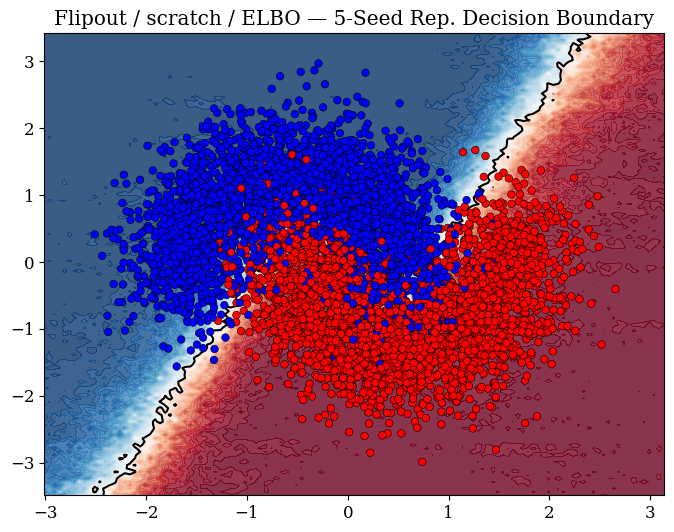

  Saved: 5seed_two_moons_flipout_scratch_elbo_boundary.png


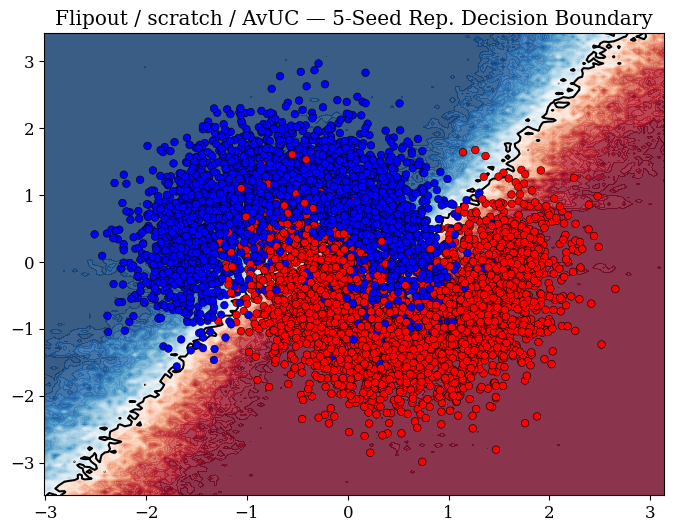

  Saved: 5seed_two_moons_flipout_scratch_avuc_boundary.png


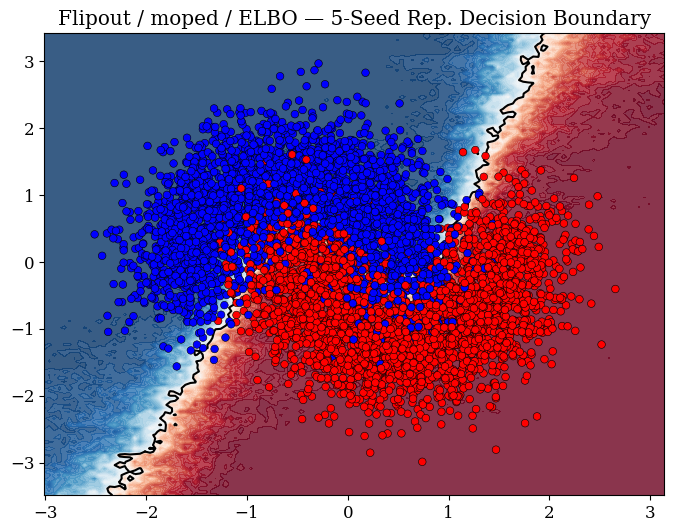

  Saved: 5seed_two_moons_flipout_moped_elbo_boundary.png


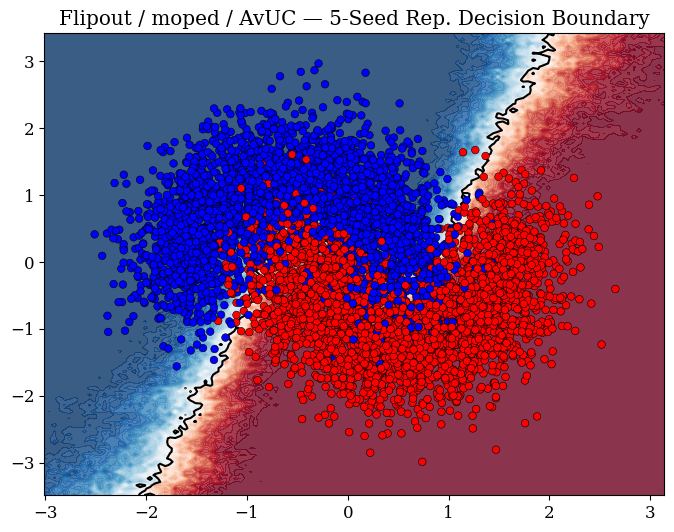

  Saved: 5seed_two_moons_flipout_moped_avuc_boundary.png


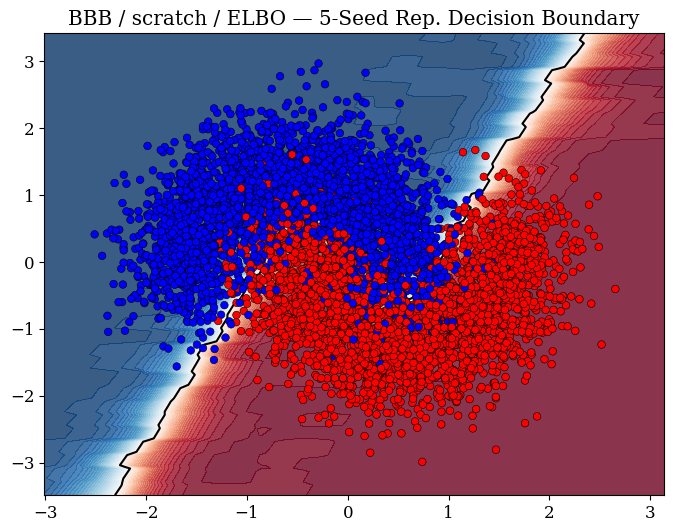

  Saved: 5seed_two_moons_bbb_scratch_elbo_boundary.png


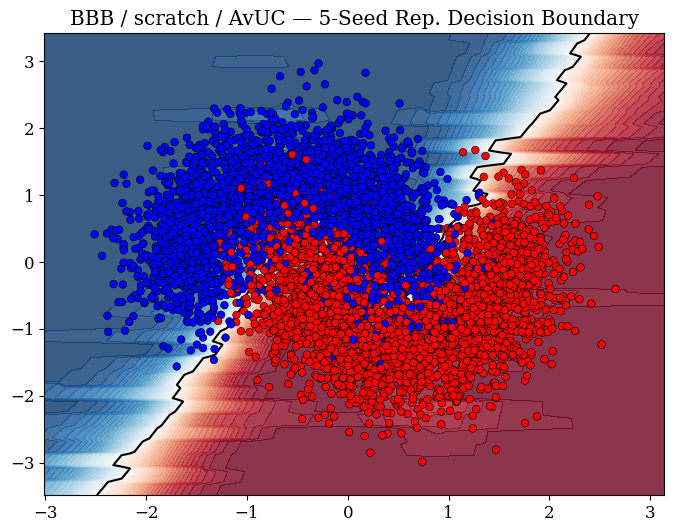

  Saved: 5seed_two_moons_bbb_scratch_avuc_boundary.png


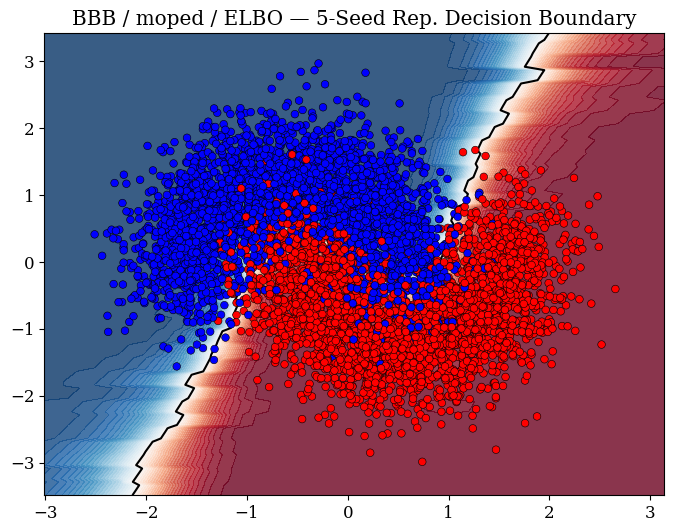

  Saved: 5seed_two_moons_bbb_moped_elbo_boundary.png


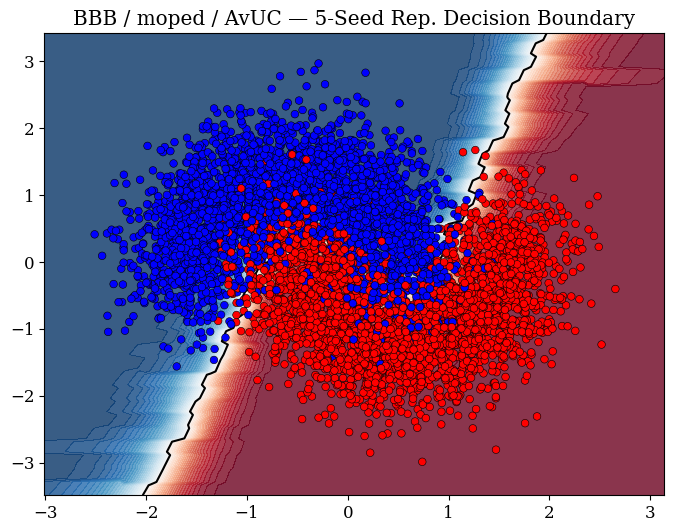

  Saved: 5seed_two_moons_bbb_moped_avuc_boundary.png

Done: 8 boundary figures


In [6]:
# Per-variant decision boundary: representative (last seed)
for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    net = all_seed_nets.get(SEEDS[-1], {}).get(vname)
    if net is None:
        print(f"  Skipping {vname}"); continue

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    plot_boundary(lambda X: bt_predict(X, net, seed=SEEDS[-1]), X_train, y_train,
                  f"{title} — 5-Seed Rep. Decision Boundary", ax=ax)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_two_moons_{vname}_boundary.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_two_moons_{vname}_boundary.png")
print(f"\nDone: {len(variant_specs)} boundary figures")

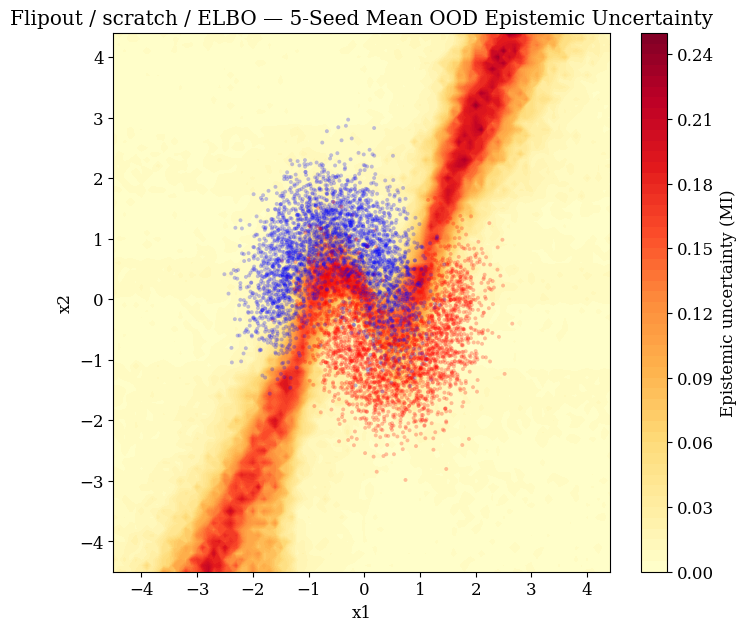

  Saved: 5seed_two_moons_flipout_scratch_elbo_ood_epistemic.png


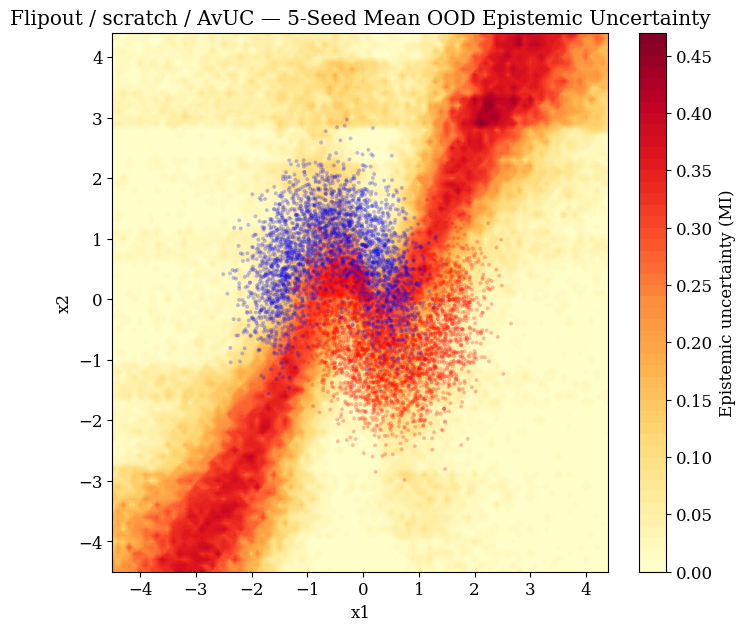

  Saved: 5seed_two_moons_flipout_scratch_avuc_ood_epistemic.png


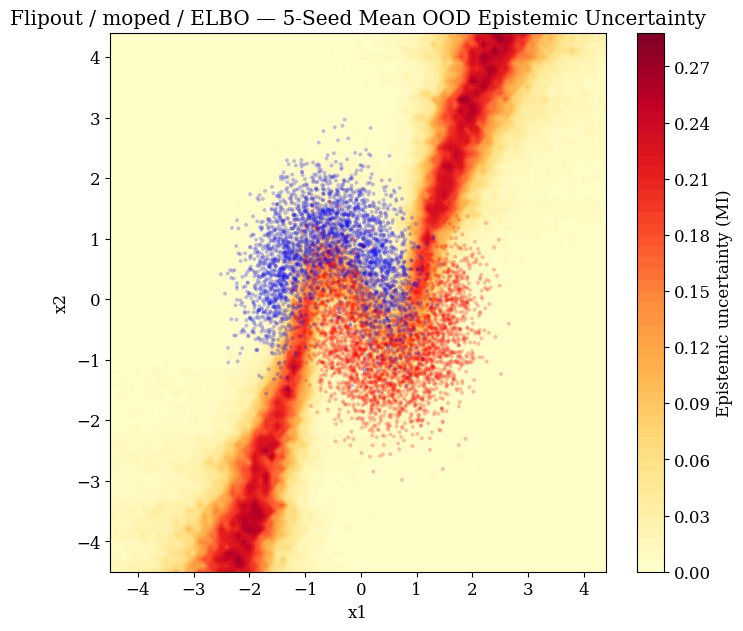

  Saved: 5seed_two_moons_flipout_moped_elbo_ood_epistemic.png


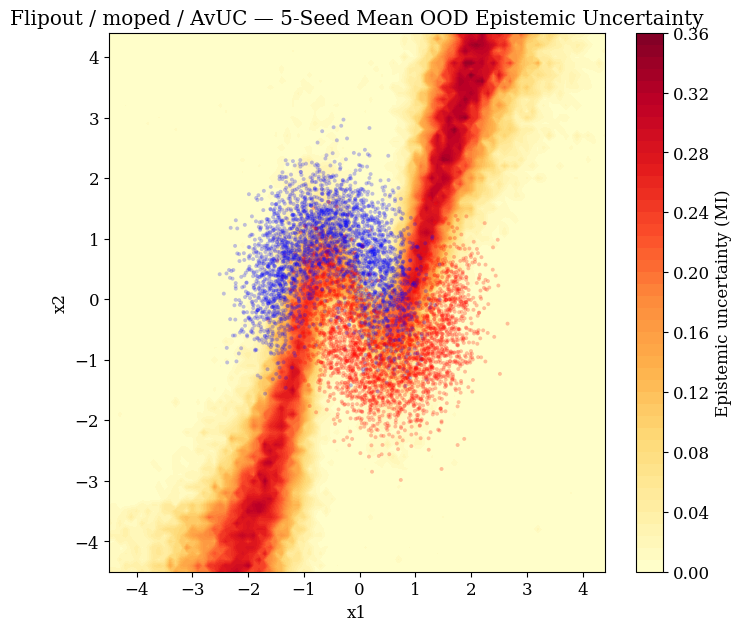

  Saved: 5seed_two_moons_flipout_moped_avuc_ood_epistemic.png


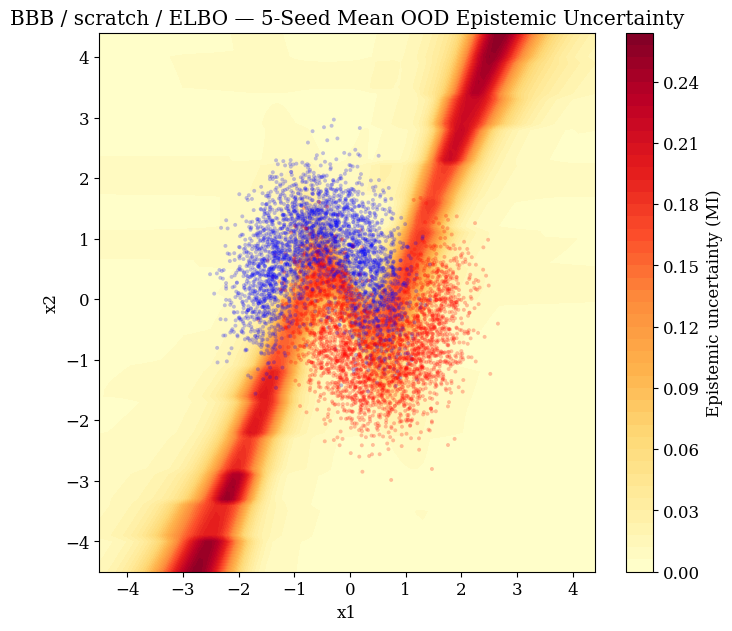

  Saved: 5seed_two_moons_bbb_scratch_elbo_ood_epistemic.png


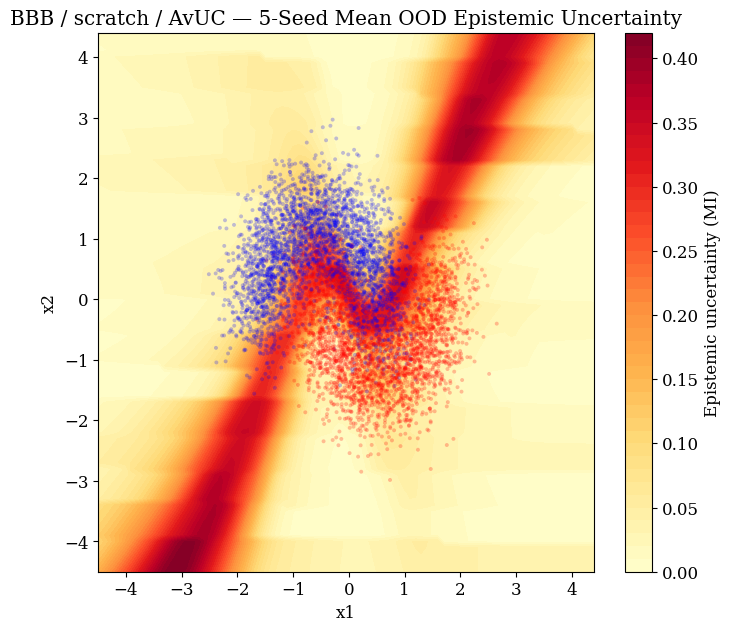

  Saved: 5seed_two_moons_bbb_scratch_avuc_ood_epistemic.png


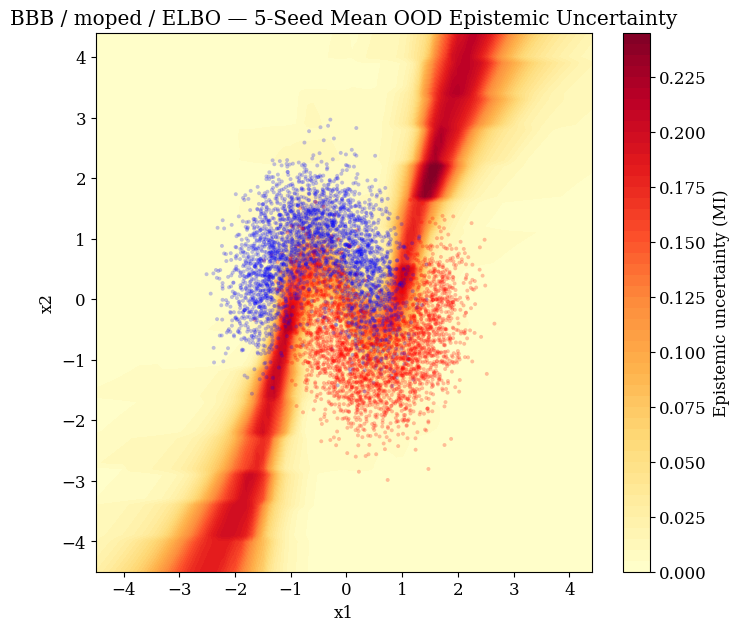

  Saved: 5seed_two_moons_bbb_moped_elbo_ood_epistemic.png


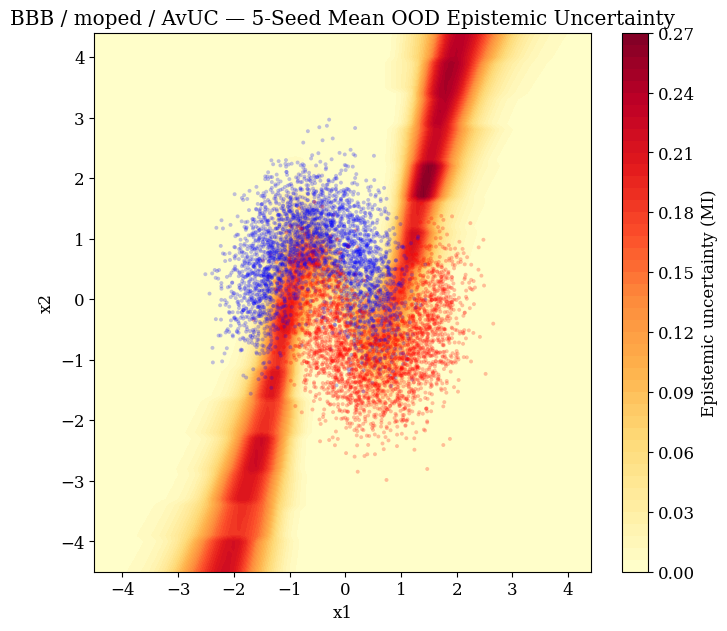

  Saved: 5seed_two_moons_bbb_moped_avuc_ood_epistemic.png

Done: 8 OOD epistemic figures


In [7]:
# Per-variant epistemic uncertainty maps: mean across seeds, on a grid
# extending beyond the training data
ext = 4.5
gx, gy = np.meshgrid(np.arange(-ext, ext, 0.1), np.arange(-ext, ext, 0.1))
epi_map_grid_np = np.c_[gx.ravel(), gy.ravel()]

def epistemic_bt(model, X_np, n_samples=50, batch_size=512, seed=None):
    """Mean epistemic uncertainty (mutual information) at each input, batched.

    Computed as entropy of the MC-mean predictive minus the mean entropy of
    the individual MC samples: the epistemic term of the standard
    total = aleatoric + epistemic predictive-entropy decomposition.

    Args:
        model: Bayesian-Torch model.
        X_np: Input array to evaluate.
        n_samples: Number of MC weight samples.
        batch_size: Rows per batch, to bound memory use.
        seed: If given, makes the MC draw reproducible (see bt_mc_forward).

    Returns:
        np.ndarray of epistemic uncertainty, one value per row of X_np.
    """
    samples = bt_predict_samples(X_np, model, n_samples=n_samples, batch_size=batch_size, seed=seed)
    mean_p = samples.mean(axis=0)
    return entropy_per_example(mean_p) - entropy_per_example(samples).mean(axis=0)

for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]

    all_epi_grids = []
    for seed in SEEDS:
        net = all_seed_nets.get(seed, {}).get(vname)
        if net is None:
            continue
        epi = epistemic_bt(net, epi_map_grid_np, n_samples=50, seed=seed)
        all_epi_grids.append(epi)
    if not all_epi_grids:
        continue
    mean_epi = np.stack(all_epi_grids).mean(axis=0).reshape(gx.shape)

    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    cf = ax.contourf(gx, gy, mean_epi, levels=50, cmap="YlOrRd")
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap="bwr",
               s=8, alpha=0.25, edgecolors="none")
    plt.colorbar(cf, ax=ax, label="Epistemic uncertainty (MI)")
    ax.set_title(f"{title} — 5-Seed Mean Epistemic Uncertainty")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_two_moons_{vname}_epistemic_map.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_two_moons_{vname}_epistemic_map.png")
print(f"\nDone: {len(variant_specs)} epistemic uncertainty figures")

/tmp/ipykernel_100704/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


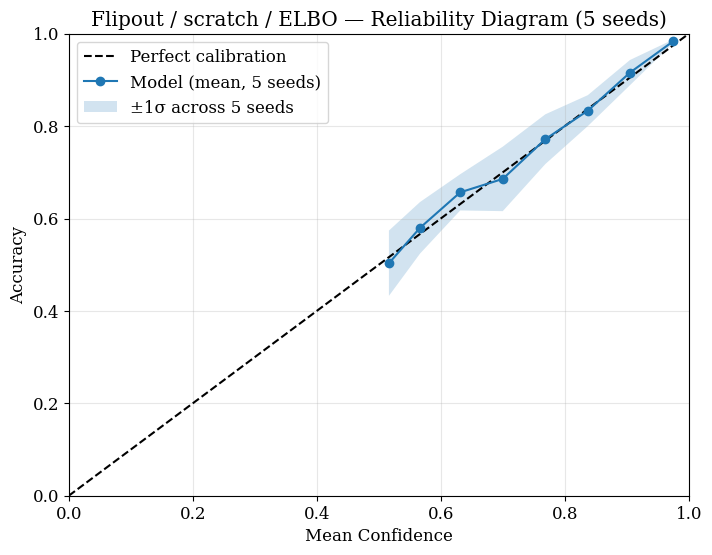

/tmp/ipykernel_100704/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Saved: 5seed_two_moons_flipout_scratch_elbo_reliability.png


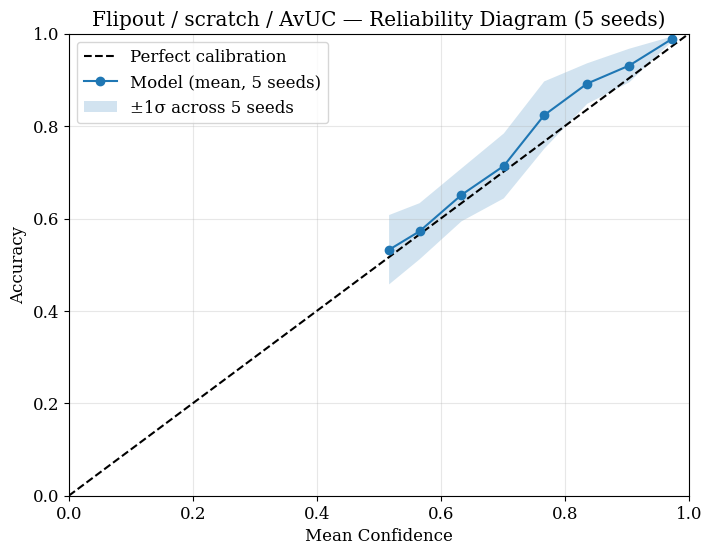

  Saved: 5seed_two_moons_flipout_scratch_avuc_reliability.png


/tmp/ipykernel_100704/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


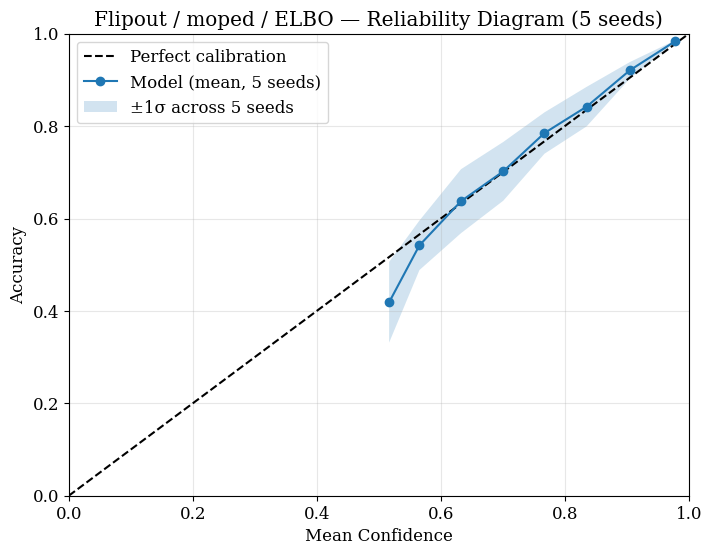

  Saved: 5seed_two_moons_flipout_moped_elbo_reliability.png


/tmp/ipykernel_100704/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


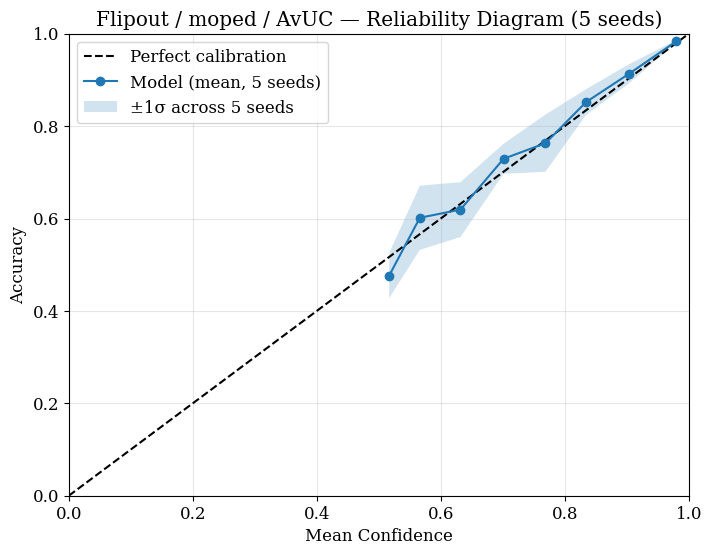

  Saved: 5seed_two_moons_flipout_moped_avuc_reliability.png


/tmp/ipykernel_100704/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


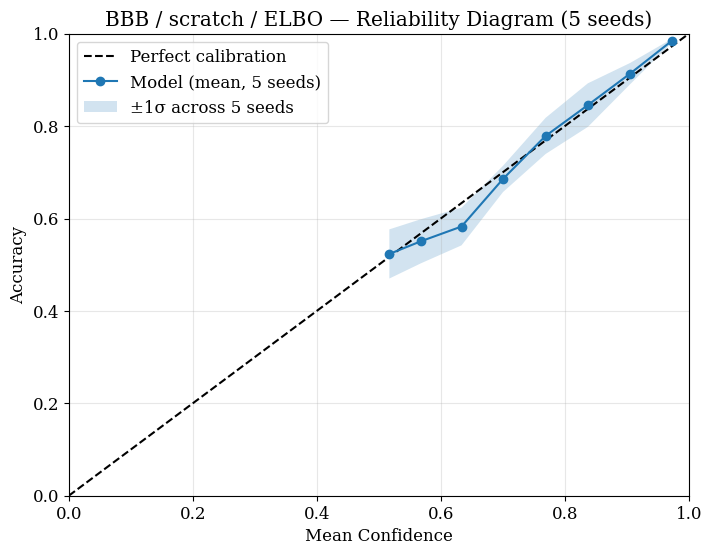

  Saved: 5seed_two_moons_bbb_scratch_elbo_reliability.png


/tmp/ipykernel_100704/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


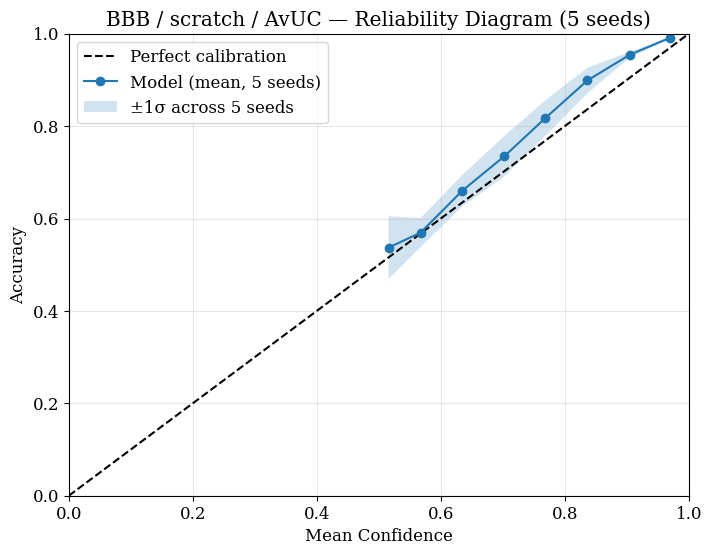

  Saved: 5seed_two_moons_bbb_scratch_avuc_reliability.png


/tmp/ipykernel_100704/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


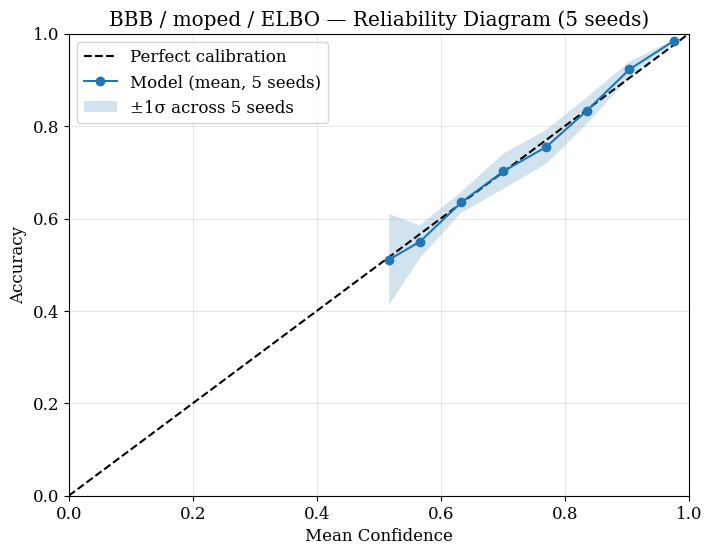

  Saved: 5seed_two_moons_bbb_moped_elbo_reliability.png


/tmp/ipykernel_100704/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


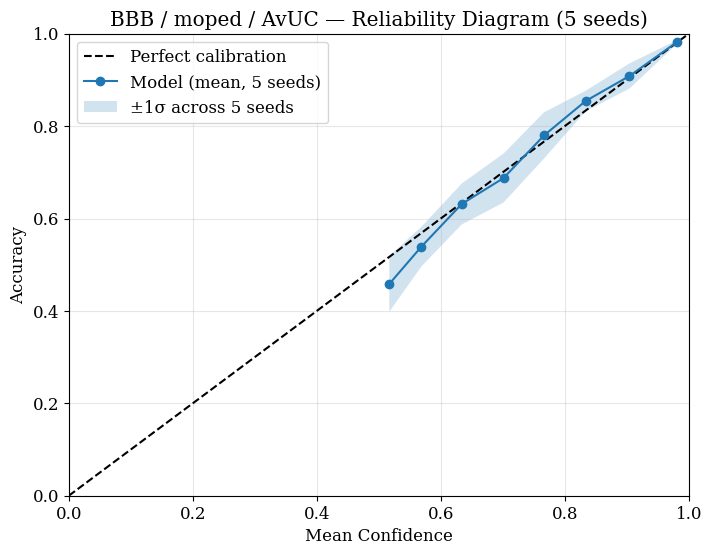

  Saved: 5seed_two_moons_bbb_moped_avuc_reliability.png

Done: 8 reliability figures


In [8]:
plot_reliability_diagrams(variant_specs, all_seed_probs, all_seed_y_test, SEEDS, FIGURES_DIR, "5seed_two_moons")
